# MAATI - pyPDF(Normal pdf files)

@author: Noorain Ansari

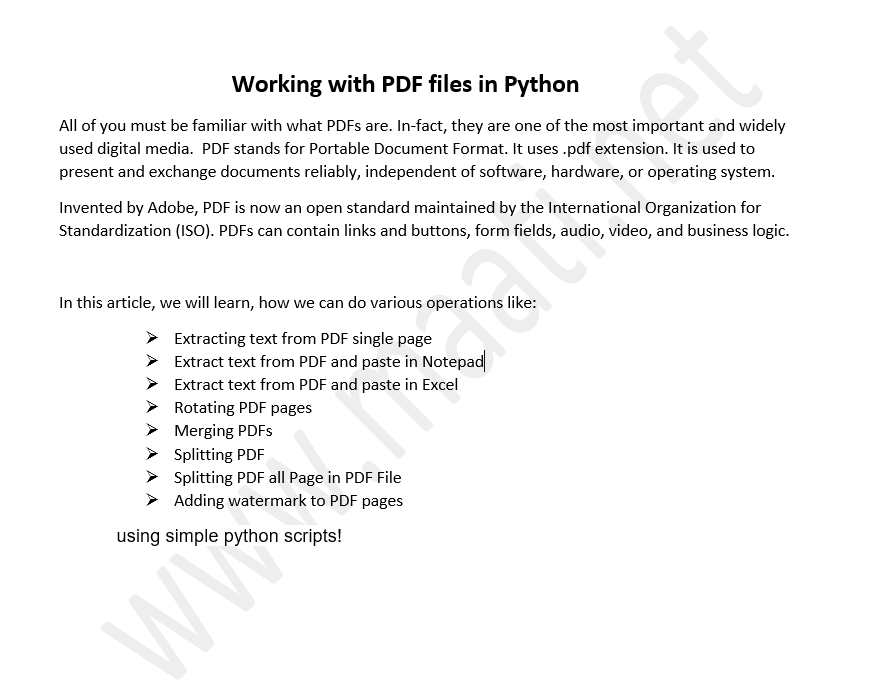

# importing required modules 

In [1]:
import PyPDF2
import pandas as pd
import xlsxwriter 
import os

# creating a pdf file object & reader object

In [2]:
pdfFileObj = open(r'python_eBook.pdf', 'rb')
pdfReader = PyPDF2.PdfFileReader(pdfFileObj)


=========================================
            Read PDF File
=========================================


In [3]:
print(pdfReader.numPages)
pageObj = pdfReader.getPage(0)

print(pageObj.extractText())


87
Introduction to Python
Heavily based on presentations by 
    Matt Huenerfauth (Penn State)
    Guido van Rossum (Google) 
    Richard P. Muller (Caltech)
    ...Monday, October 19, 2009


========================================================
            Read PDF File & paste data in NotePad
========================================================


In [4]:
#Create Notepad file
outfile = "out_text.txt"
f = open(outfile, "a") 

In [5]:
Total_Page_No=pdfReader.numPages

count=0
PDF_All_Text=""

while count < Total_Page_No:
    pageObj=pdfReader.getPage(count)
    count +=1
    PDF_All_Text += pageObj.extractText()

f.write(PDF_All_Text)

28576

# Read Notepad file

In [6]:
file1 = open("out_text.txt","r+") 

# uncommnet if you want to show notepad data
#file1.read()


========================================================
            Read PDF File & paste data in Excel
========================================================

In [7]:
pdfFileObj = open(r'PDF1.pdf', 'rb')
pdfReader = PyPDF2.PdfFileReader(pdfFileObj)

In [8]:
import xlsxwriter
Total_Page_No=pdfReader.numPages

count=0
PDF_All_Text=""

while count < Total_Page_No:
    pageObj=pdfReader.getPage(count)
    count +=1
    PDF_All_Text += pageObj.extractText()
    
    line1=PDF_All_Text.splitlines()
    

workbook = xlsxwriter.Workbook('output.xlsx')
worksheet = workbook.add_worksheet('Results')
    
while count < len(line1):
    worksheet.write(count,0,line1[count])
    count +=1

workbook.close()

=========================================
            Rotating PDF pages
=========================================

In [9]:

pdfWriter = PyPDF2.PdfFileWriter()

    # rotating each page
for page in range(pdfReader.numPages):
    pageObj = pdfReader.getPage(page)
    pageObj.rotateClockwise(90)
    pdfWriter.addPage(pageObj)

newFile = open('rotated_example.pdf', 'wb')
pdfWriter.write(newFile)
pdfFileObj.close()
newFile.close()


=========================================
            Merging PDF files
=========================================

In [10]:

# Get all the PDF filenames.
pdfFiles = []
path='C:\\Users\\DELL\\Desktop\\py_pdf(26-Jul-20)\\pdfs'
for filename in os.listdir(path):
    if filename.endswith('.pdf'):
        pdfFiles.append(filename)

pdfFiles.sort(key=str.lower)
pdfWriter = PyPDF2.PdfFileWriter()

path1=path+'\\'
# Loop through all the PDF files.
for filename in pdfFiles:
    pdfFileObj = open(path1 + filename, 'rb')
    pdfReader = PyPDF2.PdfFileReader(pdfFileObj)
    print(pdfReader.numPages)
    
    for pageNum in range(1, pdfReader.numPages):
        pageObj = pdfReader.getPage(pageNum)
        pdfWriter.addPage(pageObj)

# Save the resulting PDF to a file.
pdfOutput = open(path1 + 'Total_PDF_File.pdf', 'wb')
pdfWriter.write(pdfOutput)
pdfOutput.close()

2
1
1
10
4


# Splitting PDF Page in single PDF

In [11]:
from PyPDF2 import PdfFileReader, PdfFileWriter

In [12]:
with open("PDF1.pdf", 'rb') as infile:
    reader = PdfFileReader(infile)
    writer = PdfFileWriter()
    writer.addPage(reader.getPage(0))

    with open('output.pdf', 'wb') as outfile:
        writer.write(outfile)

# Convert ALL PDF Page in PDF file

In [13]:
infile = PdfFileReader(open('PDF1.pdf', 'rb'))

for i in range(infile.getNumPages()):
    p = infile.getPage(i)
    outfile = PdfFileWriter()
    outfile.addPage(p)
    with open('page-%02d.pdf' % i, 'wb') as f:
        outfile.write(f)

# Add watermark in pdf file

In [14]:
# original pdf file name 
minutesFile = open('python_eBook.pdf', 'rb')

pdfReader = PyPDF2.PdfFileReader(minutesFile)
minutesFirstPage = pdfReader.getPage(0)

# watermark pdf file name 
pdfWatermarkReader = PyPDF2.PdfFileReader(open('PDF Notes.pdf', 'rb'))

minutesFirstPage.mergePage(pdfWatermarkReader.getPage(0))
pdfWriter = PyPDF2.PdfFileWriter()
pdfWriter.addPage(minutesFirstPage)

for pageNum in range(1, pdfReader.numPages):
    pageObj = pdfReader.getPage(pageNum)
    pdfWriter.addPage(pageObj)

# new pdf file name 
resultPdfFile = open('watermarkedCover.pdf', 'wb')
pdfWriter.write(resultPdfFile)
minutesFile.close()
resultPdfFile.close()